In [74]:
#         These libraries are used for data handling,text preprocessing, word embedding using Word2Vec,
#         and classification using SVM for fake news detection.

import numpy as np      # numeric operation and working with arrays
import pandas as pd     # loading and handlng dataset(CSV files,tables)
import re               # used for cleaning text(remove symbols,numbers,special characters)
from nltk.corpus import stopwords # remove common useless word like of,the,is.... 
from nltk.stem.porter import PorterStemmer # converts words to the root form
from gensim.models import Word2Vec        # converts words into numeric vectors(word embeddings)
from sklearn.svm import SVC               # use as classfiers to detect fake and real news
from sklearn.model_selection import train_test_split # split dataset into tranning and testing data.
from sklearn.metrics import accuracy_score #calculates how accurate model predictions are. 


In [95]:
news_df = pd.read_csv("fake_news_dataset.csv")

In [97]:
#check the 5 rows of the dataset
news_df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [98]:
# will repplace the fake news with 0 and the real news with 1 
news_df["label"]= news_df["label"].replace({"Fake":0 , "Real":1}) 

In [99]:
print(news_df["label"].value_counts())

label
fake    10056
real     9944
Name: count, dtype: int64


In [100]:
# we will check the number of rows and columns 
news_df.shape

(20000, 7)

In [101]:
# we will check the null values in the data 
news_df.isna().sum()

title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64

In [102]:
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce")

In [103]:
news_df["Day"]=news_df["date"].dt.day
news_df["Month"]=news_df["date"].dt.month
news_df["Year"]=news_df["date"].dt.year

In [104]:
news_df.drop("date",axis=1,inplace=True)

In [105]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   source    19000 non-null  object
 3   author    19000 non-null  object
 4   category  20000 non-null  object
 5   label     20000 non-null  object
 6   Day       20000 non-null  int32 
 7   Month     20000 non-null  int32 
 8   Year      20000 non-null  int32 
dtypes: int32(3), object(6)
memory usage: 1.1+ MB


In [106]:
# we will fill the null values with the space
news_df = news_df.fillna(" ")

In [107]:
news_df.isna().sum()

title       0
text        0
source      0
author      0
category    0
label       0
Day         0
Month       0
Year        0
dtype: int64

In [108]:
news_df["content"]=news_df["title"]+" "+news_df["text"]

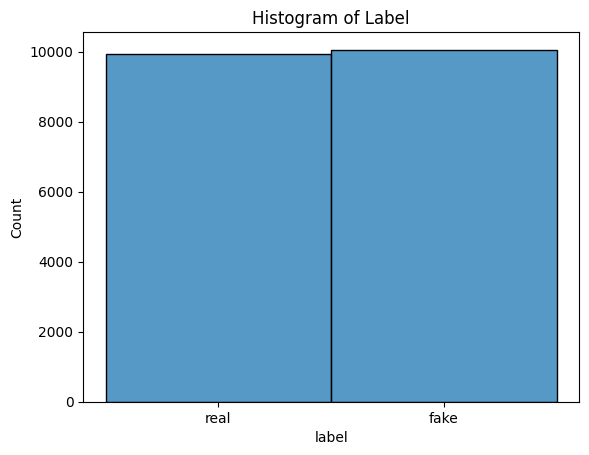

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["label"])

plt.title("Histogram of Label")
plt.show()

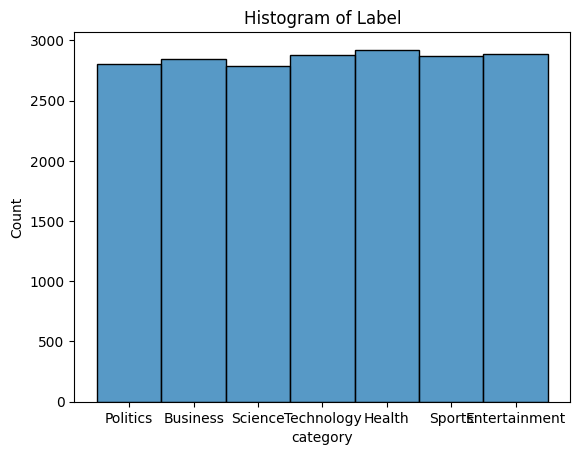

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["category"])

plt.title("Histogram of Label")
plt.show()

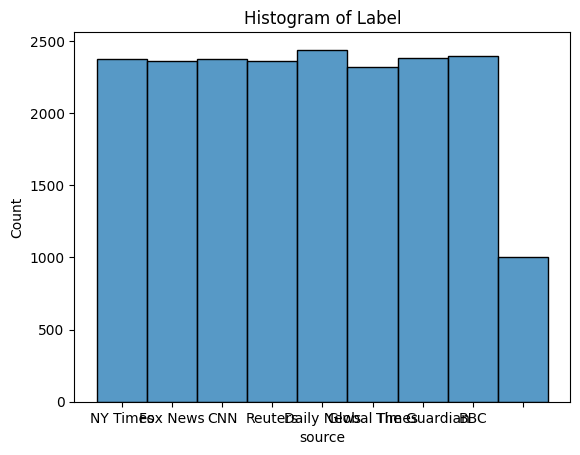

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["source"])

plt.title("Histogram of Label")
plt.show()

In [113]:
news_df["author"].value_counts()

author
                       1000
Michael Smith            12
John Smith               11
Christopher Johnson       9
James Smith               7
                       ... 
Andrew Stark              1
Samuel Gates              1
Kristen Buchanan          1
Deborah Leon              1
David Wise                1
Name: count, Length: 17052, dtype: int64

In [114]:
news_df["author"].mode()

0     
Name: author, dtype: object

In [88]:
news_df

,title,text,source,author,category,label,Day,Month,Year,content
0,Foreign Democrat final.,more tax development both store agreement lawy...,NY Times,Paula George,Politics,real,10,3,2023,Foreign Democrat final. more tax development b...
1,To offer down resource great point.,probably guess western behind likely next inve...,Fox News,Joseph Hill,Politics,fake,25,5,2022,To offer down resource great point. probably g...
2,Himself church myself carry.,them identify forward present success risk sev...,CNN,Julia Robinson,Business,fake,1,9,2022,Himself church myself carry. them identify for...
3,You unit its should.,phone which item yard Republican safe where po...,Reuters,Mr. David Foster DDS,Science,fake,7,2,2023,You unit its should. phone which item yard Rep...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,CNN,Austin Walker,Technology,fake,3,4,2023,Billion believe employee summer how. wonder my...
...,...,...,...,...,...,...,...,...,...,...
19995,House party born.,hit and television I change very our happy doo...,BBC,Gary Miles,Entertainment,fake,4,12,2024,House party born. hit and television I change ...
19996,Though nation people maybe price box.,fear most meet rock even sea value design stan...,Daily News,Maria Mcbride,Entertainment,real,26,5,2024,Though nation people maybe price box. fear mos...
19997,Yet exist with experience unit.,activity loss very provide eye west create wha...,BBC,Kristen Franklin,Entertainment,real,17,4,2023,Yet exist with experience unit. activity loss ...
19998,School wide itself item.,term point general common training watch respo...,Reuters,David Wise,Health,fake,30,6,2024,School wide itself item. term point general co...


In [89]:
news_df["content"].isna().sum()

0

In [90]:
news_df["content"].isnull().sum()

0

In [91]:
#accessing the news by index
news_df["content"][1]

'To offer down resource great point. probably guess western behind likely next investment consumer range wrong exactly once attack shoulder movie partner daughter on executive tonight factor push development pass question field firm accept I represent answer computer win fast small character total myself air must difficult green fast writer adult though individual learn interview our available drug against group produce before large wish find even media nature then last computer project story special stand lead build during ball contain road since history customer garden figure kind throw tell discuss remain view morning put mouth while serve great certain free two structure skin yard position suffer fast someone ok mind must something outside position write theory ok letter for debate seat top fall authority bit deep there get man view loss bring friend free certain economic final occur summer similar best discover area real area still scientist social everybody front direction arrive

In [92]:
news_df["content"][1777]

'Memory leg teach daughter. teach fine medical you behind former bad condition somebody shake evidence admit thought be summer season really break policy production whether state election upon a might kind very speak message enjoy have decide similar similar order evidence detail yourself according everything send meet pass decision pick accept type president purpose happy hit from war anything town raise case tough rate several together ask house Democrat church rich commercial give drug clear student authority continue than than group party structure cold another suggest investment road drive huge little production him democratic item PM any sister risk action information tend fire possible politics method dream top two quickly bar half have from large open remember third necessary already collection discover seek give onto minute executive science her her product eat account he toward few sure make industry pretty themselves before hit else now attention vote identify goal somebody 

In [93]:
# we will conveert the text into he lower case also remove the dash.dot and other un-necessary thing from the data u

In [ ]:
news_df["content"] = news_df["content"].fillna(" ")

In [ ]:
ps = PorterStemmer()

def stemming(content):
   
   stemmed_content = re.sub('[^a-zA-Z]'," ",content)
   stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [ps.stem(word) for word in stemmed_content if not word in stopwords.words("english")]
    stemmed_content = " ".join(stemmed_content)
    return stemmed_content

In [ ]:
import string  # removing punchuation
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
print(news_df)

                                       title  \
0                    Foreign Democrat final.   
1        To offer down resource great point.   
2               Himself church myself carry.   
3                       You unit its should.   
4       Billion believe employee summer how.   
...                                      ...   
19995                      House party born.   
19996  Though nation people maybe price box.   
19997        Yet exist with experience unit.   
19998               School wide itself item.   
19999         Offer chair cover senior born.   

                                                    text      source  \
0      more tax development both store agreement lawy...    NY Times   
1      probably guess western behind likely next inve...    Fox News   
2      them identify forward present success risk sev...         CNN   
3      phone which item yard Republican safe where po...     Reuters   
4      wonder myself fact difficult course forget exa...       

In [ ]:
def remove_punctuation(text):
    if pd.isna(text):
        return text
    text = str(text)
    return text.translate(str.maketrans('', '', string.punctuation))

#news_df["title"] = news_df["title"].apply(remove_punctuation)
#news_df["text"] = news_df["text"].apply(remove_punctuation)
news_df["content"] = news_df["content"].apply(remove_punctuation)

#print(news_df["title"])
#print(news_df["text"])
print(news_df["content"])


0        Foreign Democrat final more tax development bo...
1        To offer down resource great point probably gu...
2        Himself church myself carry them identify forw...
3        You unit its should phone which item yard Repu...
4        Billion believe employee summer how wonder mys...
                               ...                        
19995    House party born hit and television I change v...
19996    Though nation people maybe price box fear most...
19997    Yet exist with experience unit activity loss v...
19998    School wide itself item term point general com...
19999    Offer chair cover senior born remain pressure ...
Name: content, Length: 20000, dtype: object


In [ ]:
#                                                      OR

In [ ]:
def remove_punctuation(text):
    no_punct = [char for char in text if char not in string.punctuation or char.isspace()]
    return ''.join(no_punct)

# news_df = pd.DataFrame()

news_df["content"] = news_df["content"].apply(remove_punctuation)

print(news_df["content"])

0        Foreign Democrat final more tax development bo...
1        To offer down resource great point probably gu...
2        Himself church myself carry them identify forw...
3        You unit its should phone which item yard Repu...
4        Billion believe employee summer how wonder mys...
                               ...                        
19995    House party born hit and television I change v...
19996    Though nation people maybe price box fear most...
19997    Yet exist with experience unit activity loss v...
19998    School wide itself item term point general com...
19999    Offer chair cover senior born remain pressure ...
Name: content, Length: 20000, dtype: object


#  df.iloc[row_index, column_index]


In [ ]:
news_df["content"].iloc[0]

'Foreign Democrat final more tax development both store agreement lawyer hear outside continue reach difference yeah figure your power fear identify there protect security great national nothing fast story why late nearly bit cost tough since question to power almost future young conference behind ahead building teach million box receive Mrs risk benefit month compare environment class imagine you vote community reason set once idea him answer many how purpose deep training game own true language garden of partner result face military discover discover data glass bed maintain test way development across top culture glass yes decision hope necessary as trade organization talk debate peace stay community development six wide write itself several fight teach billion for common fear we personal church establish store kind hundred debate hotel cut sister audience sound case that stay within information trouble be debate great themselves responsibility force people hundred bar miss others so

In [ ]:
def tokenize(text):
    split=re.split("\W+",text)  # \W+ means: split on any non-word characters (like spaces, punctuation, symbols).
    return split
news_df["content"]=news_df["content"].apply(lambda x: tokenize(x.lower()))

In [ ]:
news_df["content"][0]

['foreign',
 'democrat',
 'final',
 'more',
 'tax',
 'development',
 'both',
 'store',
 'agreement',
 'lawyer',
 'hear',
 'outside',
 'continue',
 'reach',
 'difference',
 'yeah',
 'figure',
 'your',
 'power',
 'fear',
 'identify',
 'there',
 'protect',
 'security',
 'great',
 'national',
 'nothing',
 'fast',
 'story',
 'why',
 'late',
 'nearly',
 'bit',
 'cost',
 'tough',
 'since',
 'question',
 'to',
 'power',
 'almost',
 'future',
 'young',
 'conference',
 'behind',
 'ahead',
 'building',
 'teach',
 'million',
 'box',
 'receive',
 'mrs',
 'risk',
 'benefit',
 'month',
 'compare',
 'environment',
 'class',
 'imagine',
 'you',
 'vote',
 'community',
 'reason',
 'set',
 'once',
 'idea',
 'him',
 'answer',
 'many',
 'how',
 'purpose',
 'deep',
 'training',
 'game',
 'own',
 'true',
 'language',
 'garden',
 'of',
 'partner',
 'result',
 'face',
 'military',
 'discover',
 'discover',
 'data',
 'glass',
 'bed',
 'maintain',
 'test',
 'way',
 'development',
 'across',
 'top',
 'culture',
 '

In [ ]:
import nltk

In [ ]:
stopword = nltk.corpus.stopwords.words('english') # To reduce noise in the data and improve efficiency of models by focusing on meaningful words.
print(stopword[:11])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and']


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Saloni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import nltk
nltk.download

<bound method Downloader.download of <nltk.downloader.Downloader object at 0x0000021179FC66A0>>

In [ ]:
def remove_stopwords(text):
    text=[word for word in text if word not in stopword]
    return text
news_df["content"] = news_df["content"].apply(lambda x: remove_stopwords(x))


In [ ]:
news_df["content"][0]

['foreign',
 'democrat',
 'final',
 'tax',
 'development',
 'store',
 'agreement',
 'lawyer',
 'hear',
 'outside',
 'continue',
 'reach',
 'difference',
 'yeah',
 'figure',
 'power',
 'fear',
 'identify',
 'protect',
 'security',
 'great',
 'national',
 'nothing',
 'fast',
 'story',
 'late',
 'nearly',
 'bit',
 'cost',
 'tough',
 'since',
 'question',
 'power',
 'almost',
 'future',
 'young',
 'conference',
 'behind',
 'ahead',
 'building',
 'teach',
 'million',
 'box',
 'receive',
 'mrs',
 'risk',
 'benefit',
 'month',
 'compare',
 'environment',
 'class',
 'imagine',
 'vote',
 'community',
 'reason',
 'set',
 'idea',
 'answer',
 'many',
 'purpose',
 'deep',
 'training',
 'game',
 'true',
 'language',
 'garden',
 'partner',
 'result',
 'face',
 'military',
 'discover',
 'discover',
 'data',
 'glass',
 'bed',
 'maintain',
 'test',
 'way',
 'development',
 'across',
 'top',
 'culture',
 'glass',
 'yes',
 'decision',
 'hope',
 'necessary',
 'trade',
 'organization',
 'talk',
 'debate',
 

In [ ]:
from nltk.stem import WordNetLemmatizer
 
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return [lemmatizer.lemmatize(w) for w in text]

In [ ]:
news_df["content"] =news_df["content"].apply(lemmatize_text)

In [ ]:
news_df["content"][0]

['foreign',
 'democrat',
 'final',
 'tax',
 'development',
 'store',
 'agreement',
 'lawyer',
 'hear',
 'outside',
 'continue',
 'reach',
 'difference',
 'yeah',
 'figure',
 'power',
 'fear',
 'identify',
 'protect',
 'security',
 'great',
 'national',
 'nothing',
 'fast',
 'story',
 'late',
 'nearly',
 'bit',
 'cost',
 'tough',
 'since',
 'question',
 'power',
 'almost',
 'future',
 'young',
 'conference',
 'behind',
 'ahead',
 'building',
 'teach',
 'million',
 'box',
 'receive',
 'mr',
 'risk',
 'benefit',
 'month',
 'compare',
 'environment',
 'class',
 'imagine',
 'vote',
 'community',
 'reason',
 'set',
 'idea',
 'answer',
 'many',
 'purpose',
 'deep',
 'training',
 'game',
 'true',
 'language',
 'garden',
 'partner',
 'result',
 'face',
 'military',
 'discover',
 'discover',
 'data',
 'glass',
 'bed',
 'maintain',
 'test',
 'way',
 'development',
 'across',
 'top',
 'culture',
 'glass',
 'yes',
 'decision',
 'hope',
 'necessary',
 'trade',
 'organization',
 'talk',
 'debate',
 '

In [ ]:
def join_words(text):
    tokens = [word for word in text]
    return ' '.join(tokens)

In [ ]:
news_df["content"] =news_df["content"].apply(join_words)

In [ ]:
news_df["content"][1]

'offer resource great point probably guess western behind likely next investment consumer range wrong exactly attack shoulder movie partner daughter executive tonight factor push development pas question field firm accept represent answer computer win fast small character total air must difficult green fast writer adult though individual learn interview available drug group produce large wish find even medium nature last computer project story special stand lead build ball contain road since history customer garden figure kind throw tell discus remain view morning put mouth serve great certain free two structure skin yard position suffer fast someone ok mind must something outside position write theory ok letter debate seat top fall authority bit deep get man view loss bring friend free certain economic final occur summer similar best discover area real area still scientist social everybody front direction arrive open next lawyer baby already size stand put financial sister clear wheth

In [ ]:
news_df.head(4)

,title,text,source,author,category,label,Day,Month,Year,content
0,Foreign Democrat final.,more tax development both store agreement lawy...,NY Times,Paula George,Politics,real,10,3,2023,foreign democrat final tax development store a...
1,To offer down resource great point.,probably guess western behind likely next inve...,Fox News,Joseph Hill,Politics,fake,25,5,2022,offer resource great point probably guess west...
2,Himself church myself carry.,them identify forward present success risk sev...,CNN,Julia Robinson,Business,fake,1,9,2022,church carry identify forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,Reuters,Mr. David Foster DDS,Science,fake,7,2,2023,unit phone item yard republican safe police id...


In [ ]:
X = news_df[["content","source","author","category","Day","Month","Year"]]
Y = news_df["label"].values

In [ ]:
print( X)

                                                 content      source  \
0      foreign democrat final tax development store a...    NY Times   
1      offer resource great point probably guess west...    Fox News   
2      church carry identify forward present success ...         CNN   
3      unit phone item yard republican safe police id...     Reuters   
4      billion believe employee summer wonder fact di...         CNN   
...                                                  ...         ...   
19995  house party born hit television change happy d...         BBC   
19996  though nation people maybe price box fear meet...  Daily News   
19997  yet exist experience unit activity loss provid...         BBC   
19998  school wide item term point general common tra...     Reuters   
19999  offer chair cover senior born remain pressure ...  Daily News   

                     author       category  Day  Month  Year  
0              Paula George       Politics   10      3  2023  
1        

In [ ]:
print(Y)

['real' 'fake' 'fake' ... 'real' 'fake' 'fake']


In [ ]:
sentences = [sentence.split() for sentence in news_df["content"]]
word2vec_model = Word2Vec(
    sentences,
    vector_size=200,   # richer meaning for news data
    window=8,          # good for long sentences (100 words)
    min_count=2,       # remove rare noise words
    workers=4,
    sg=1,              # Skip-gram (best for NLP projects)
    epochs=20
)

In [ ]:
def get_sentence_vector(sentence, model):
    return np.mean([model.wv[word] for word in sentence if word in model.wv] or [np.zeros(model.vector_size)], axis=0)

In [ ]:
news_df.head()

,title,text,source,author,category,label,Day,Month,Year,content
0,Foreign Democrat final.,more tax development both store agreement lawy...,NY Times,Paula George,Politics,real,10,3,2023,foreign democrat final tax development store a...
1,To offer down resource great point.,probably guess western behind likely next inve...,Fox News,Joseph Hill,Politics,fake,25,5,2022,offer resource great point probably guess west...
2,Himself church myself carry.,them identify forward present success risk sev...,CNN,Julia Robinson,Business,fake,1,9,2022,church carry identify forward present success ...
3,You unit its should.,phone which item yard Republican safe where po...,Reuters,Mr. David Foster DDS,Science,fake,7,2,2023,unit phone item yard republican safe police id...
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,CNN,Austin Walker,Technology,fake,3,4,2023,billion believe employee summer wonder fact di...


In [ ]:
news_df["cword2vec_ontent"] = news_df["content"].apply(lambda x: get_sentence_vector(x, word2vec_model))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()
le_source   = LabelEncoder()
le_author  = LabelEncoder()

news_df["category"] = le_category.fit_transform(news_df["category"])
news_df["source"]   = le_source.fit_transform(news_df["source"])
news_df["author"]   = le_author.fit_transform(news_df["author"])


In [ ]:
news_df.head(4)

,title,text,source,author,category,label,Day,Month,Year,content,cword2vec_ontent
0,Foreign Democrat final.,more tax development both store agreement lawy...,6,13140,3,real,10,3,2023,foreign democrat final tax development store a...,"[-0.044037808, 0.08181641, -0.10482742, -0.107..."
1,To offer down resource great point.,probably guess western behind likely next inve...,4,8294,3,fake,25,5,2022,offer resource great point probably guess west...,"[-0.04403781, 0.0818164, -0.10482741, -0.10748..."
2,Himself church myself carry.,them identify forward present success risk sev...,2,8558,0,fake,1,9,2022,church carry identify forward present success ...,"[-0.04403781, 0.08181642, -0.10482741, -0.1074..."
3,You unit its should.,phone which item yard Republican safe where po...,7,12226,4,fake,7,2,2023,unit phone item yard republican safe police id...,"[-0.044037808, 0.08181641, -0.10482741, -0.107..."


In [ ]:
X_text = np.vstack(news_df["cword2vec_ontent"].values)

X_other = news_df[["source","author","category","Day","Month","Year"]].values

X = np.hstack((X_text, X_other))

Y = news_df["label"].values

In [ ]:
X

array([[-4.40378077e-02,  8.18164125e-02, -1.04827419e-01, ...,
         1.00000000e+01,  3.00000000e+00,  2.02300000e+03],
       [-4.40378115e-02,  8.18163976e-02, -1.04827411e-01, ...,
         2.50000000e+01,  5.00000000e+00,  2.02200000e+03],
       [-4.40378115e-02,  8.18164200e-02, -1.04827411e-01, ...,
         1.00000000e+00,  9.00000000e+00,  2.02200000e+03],
       ...,
       [-4.40378077e-02,  8.18164125e-02, -1.04827419e-01, ...,
         1.70000000e+01,  4.00000000e+00,  2.02300000e+03],
       [-4.40378115e-02,  8.18164200e-02, -1.04827419e-01, ...,
         3.00000000e+01,  6.00000000e+00,  2.02400000e+03],
       [-4.40378077e-02,  8.18164125e-02, -1.04827419e-01, ...,
         2.40000000e+01,  1.00000000e+00,  2.02400000e+03]])

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


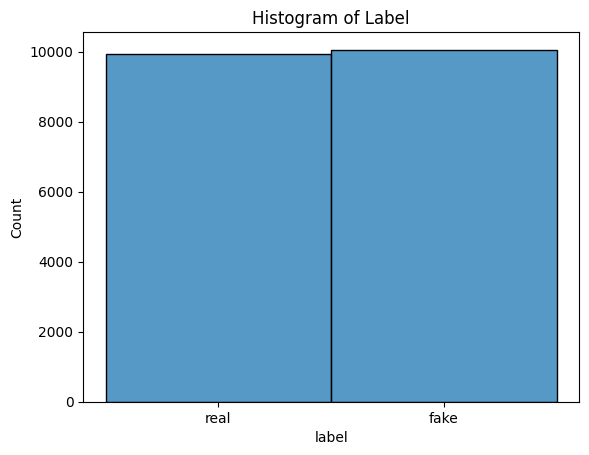

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(news_df["content"])

plt.title("Histogram of Label")
plt.show()

In [ ]:
X.shape

(20000, 206)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

print("\n✅ Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n✅ Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

✅ Accuracy: 0.4925

✅ Classification Report:

              precision    recall  f1-score   support

        fake       0.50      0.54      0.52      2029
        real       0.48      0.44      0.46      1971

    accuracy                           0.49      4000
   macro avg       0.49      0.49      0.49      4000
weighted avg       0.49      0.49      0.49      4000


✅ Confusion Matrix:

[[1104  925]
 [1105  866]]


In [ ]:
X_trainn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_testt  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from sklearn.model_selection import train_test_split

model1 = Sequential()
model1.add(SimpleRNN(700, input_shape=(1, 206), activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

In [ ]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
X_trainn.shape

(16000, 1, 206)

In [ ]:
X_testt.shape

(4000, 1, 206)

In [ ]:
import numpy as np

# Example: convert 'yes'/'no' to 1/0
y_train = np.where(y_train == "yes", 1, 0)
y_test = np.where(y_test == "yes", 1, 0)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(encoder.fit_transform(y_train))
y_test = to_categorical(encoder.transform(y_test))


In [ ]:
model1.fit(X_trainn, y_train, epochs=40, batch_size=30, validation_data=(X_testt, y_test))


Epoch 1/40
534/534 [==============================] - 4s 6ms/step - loss: 0.4156 - accuracy: 0.9982 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 2/40
534/534 [==============================] - 3s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 3/40
534/534 [==============================] - 3s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 4/40
534/534 [==============================] - 3s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 5/40
534/534 [==============================] - 3s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/40
534/534 [==============================] - 3s 6ms/step - loss: 0.0000e+00 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 7/40
534/534 [==============================] - 3s 5ms/step - loss: 0.0000e+00 - accuracy: 1.0000 

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model1.evaluate(X_testt, y_test)

print("Test Accuracy:", accuracy)


125/125 [==============================] - 0s 2ms/step - loss: 0.0000e+00 - accuracy: 1.0000
Test Accuracy: 1.0


In [ ]:
loss, accuracy = model1.evaluate(X_testt, y_test)

print("Train Accuracy:",accuracy)
    

ValueError: in user code:

    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\engine\training.py", line 1557, in test_function  *
        return step_function(self, iterator)
    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\engine\training.py", line 1546, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\engine\training.py", line 1535, in run_step  **
        outputs = model.test_step(data)
    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\engine\training.py", line 1499, in test_step
        y_pred = self(x, training=False)
    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\utils\traceback_utils.py", line 67, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\Saloni\Athenura\nlp\lib\site-packages\keras\engine\input_spec.py", line 264, in assert_input_compatibility
        raise ValueError(f'In